Overview:
Evaluates and compares RAG bot vs Agentic bot across 7 metrics:

Metric                  Description
----------------------  --------------------------------------------------
Intent Accuracy         Unified LLM judge: did response address correct intent?
                        (same definition applied to both bots)
Response Relevance      0-10 LLM judge score normalized to 0-1
                        (judged against POLICIES dict, not Bitext ground truth)
Hallucination Rate      RAG: grounded against retrieved chunk text
                        Agentic: grounded against POLICIES dict & Tool Outputs
Multi-step Success      Agentic only - RAG reported as N/A (architectural limit)
                        Cited: Neha & Bhati 2025 Table I
Average Latency         Wall-clock seconds per query
BLEU                    n-gram precision vs held-out ground truth
ROUGE-L                 LCS-based recall vs held-out ground truth

Tool Invocation Correctness is reported separately for Agentic only.
6 visualizations are produced.
An academic conclusion is generated via a single properly parameterized LLM call.

Key fixes vs v1:
- Intent accuracy uses a single unified metric definition for both bots
- Relevance judged against POLICIES (neutral reference), not Bitext ground truth
- RAG hallucination check uses retrieved_texts column (actual chunk content)
- Agentic hallucination check grounds against POLICIES & Tool Outputs
- Multi-step: RAG correctly marked N/A per architectural analysis
- conclusion_prompt defined before call_llm(); temperature and max_tokens
  passed correctly into the function
- BLEU and ROUGE pulled from result CSVs (computed in NB1 and NB2)

In [9]:
# STEP 0 - Install / imports

!pip install groq tqdm rouge-score sacrebleu -q

import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from groq import Groq

print("Imports OK")

from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('/content/drive/MyDrive/benchmark_queries.csv', 'benchmark_queries.csv')
shutil.copy('/content/drive/MyDrive/rag_results.csv',       'rag_results.csv')
shutil.copy('/content/drive/MyDrive/agentic_results.csv',   'agentic_results.csv')
print("All 3 files restored.")

Imports OK
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All 3 files restored.


In [10]:
# STEP 1 - Configuration

from google.colab import userdata
api_key = userdata.get('CST_API')

RAG_RESULTS_CSV     = "rag_results.csv"
AGENTIC_RESULTS_CSV = "agentic_results.csv"
GROQ_MODEL          = "llama-3.1-8b-instant"

# The shared neutral reference used for relevance and hallucination scoring.
# Both bots are judged against this same policy document,
# eliminating the distribution bias of judging RAG against its own source data.
POLICIES = {
    "refund_window"     : "30 days from purchase",
    "cancellation_fee"  : "No fee if cancelled within 24 hours",
    "delivery_standard" : "5-7 business days",
    "delivery_express"  : "2-3 business days",
    "payment_methods"   :["credit card", "debit card", "PayPal", "UPI"],
    "return_condition"  : "Item must be unused and in original packaging",
    "support_hours"     : "Monday to Friday, 9 AM to 6 PM IST",
    "complaint_sla"     : "Complaints are reviewed within 48 hours"
}
POLICIES_TEXT = json.dumps(POLICIES, indent=2)

# Expected correct tool per intent (for Agentic tool invocation scoring)
CORRECT_TOOLS = {
    "track_order"        : "check_order_status()",
    "get_refund"         : "process_refund()",
    "cancel_order"       : "cancel_order()",
    "payment_issue"      : "check_payment()",
    "contact_human_agent": "escalate_to_human()",
    "complaint"          : "log_complaint()"
}

groq_client = Groq(api_key=api_key)
print("Config loaded.")
print(f"   LLM judge : {GROQ_MODEL}")


Config loaded.
   LLM judge : llama-3.1-8b-instant


In [11]:
# STEP 2 - Load Results

df_rag     = pd.read_csv(RAG_RESULTS_CSV)
df_agentic = pd.read_csv(AGENTIC_RESULTS_CSV)

print(f"RAG results     : {len(df_rag)} rows")
print(f"Agentic results : {len(df_agentic)} rows")

assert set(df_rag["id"].tolist()) == set(df_agentic["id"].tolist()), \
    "ID mismatch between result files. Re-run notebooks 1 and 2."

print("\nRAG columns    :", list(df_rag.columns))
print("Agentic columns:", list(df_agentic.columns))

RAG results     : 60 rows
Agentic results : 60 rows

RAG columns    : ['id', 'instruction', 'ground_truth', 'bot_response', 'intent', 'is_multi_step', 'latency_seconds', 'retrieved_intents', 'retrieved_texts', 'rouge1', 'rougeL', 'bleu']
Agentic columns: ['id', 'instruction', 'ground_truth', 'bot_response', 'intent', 'is_multi_step', 'latency_seconds', 'tools_called', 'sub_intents', 'tool_success', 'intent_detected', 'reasoning_trace', 'rouge1', 'rougeL', 'bleu']


In [12]:
# STEP 3 - LLM Judge Helper

def call_llm(prompt: str, max_retries: int = 3,
             max_tokens: int = 256, temperature: float = 0.1) -> str:
    """Groq Llama 3.1 with exponential backoff retry.
    max_tokens and temperature are explicit parameters, not hardcoded.
    """
    for attempt in range(1, max_retries + 1):
        try:
            response = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                max_tokens=max_tokens,
                temperature=temperature
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            wait = 2 ** attempt
            if attempt < max_retries:
                time.sleep(wait)
            else:
                return "5"   # neutral fallback for scoring calls

In [13]:
# STEP 4a - Intent Accuracy (Unified Metric)
# Both bots are evaluated with the same LLM judge prompt.

INTENT_CACHE = "intent_scores.csv"

def score_intent_unified(instruction, intent, bot_response):
    prompt = f"""A customer sent this query: {instruction}
The ground truth intent is: {intent}
The bot responded with: {bot_response}

Does the bot response correctly address the customer's {intent.replace('_', ' ')} request?
Answer ONLY Yes or No."""
    raw = call_llm(prompt)
    return 1 if "yes" in raw.lower() else 0

if os.path.exists(INTENT_CACHE):
    df_intent = pd.read_csv(INTENT_CACHE)
    print(f"Loaded cached intent scores ({len(df_intent)} rows)")
else:
    intent_rag     =[]
    intent_agentic =[]

    print("Scoring RAG intent accuracy...")
    for _, row in tqdm(df_rag.iterrows(), total=len(df_rag), desc="RAG intent"):
        s = score_intent_unified(row["instruction"], row["intent"], row["bot_response"])
        intent_rag.append(s)
        time.sleep(0.3)

    print("Scoring Agentic intent accuracy...")
    for _, row in tqdm(df_agentic.iterrows(), total=len(df_agentic), desc="Agentic intent"):
        s = score_intent_unified(row["instruction"], row["intent"], row["bot_response"])
        intent_agentic.append(s)
        time.sleep(0.3)

    df_intent = pd.DataFrame({
        "id"             : df_rag["id"].tolist(),
        "intent"         : df_rag["intent"].tolist(),
        "is_multi_step"  : df_rag["is_multi_step"].tolist(),
        "rag_intent"     : intent_rag,
        "agentic_intent" : intent_agentic
    })
    df_intent.to_csv(INTENT_CACHE, index=False)
    print(f"Saved to {INTENT_CACHE}")

rag_intent_acc     = df_intent["rag_intent"].mean() * 100
agentic_intent_acc = df_intent["agentic_intent"].mean() * 100

print(f"\nIntent Accuracy (unified LLM judge - same metric for both bots)")
print(f"   RAG     : {rag_intent_acc:.1f}%")
print(f"   Agentic : {agentic_intent_acc:.1f}%")

# STEP 4b - Response Relevance (0-1)
# Judged against POLICIES (neutral reference), not Bitext ground truth.
# This removes the distribution bias that artificially favored RAG in v1.

RELEVANCE_CACHE = "relevance_scores.csv"

def score_relevance(query, bot_response):
    """Score how well the response reflects the shared POLICIES document."""
    prompt = f"""Score this customer support response from 0 to 10 based on:
- How accurately it reflects the company policies below
- How helpful and relevant it is to the customer query
- Whether it avoids making up information not in the policies

Company Policies:
{POLICIES_TEXT}

Customer Query: {query}
Bot Response: {bot_response}

10 = perfectly accurate and helpful per policies
5  = partially correct or partially helpful
0  = contradicts policies or completely unhelpful

Return ONLY a single integer between 0 and 10. No explanation."""
    raw = call_llm(prompt)
    try:
        score = int(raw.strip().split()[0])
        return max(0, min(10, score)) / 10.0
    except:
        return 0.5

if os.path.exists(RELEVANCE_CACHE):
    df_scores = pd.read_csv(RELEVANCE_CACHE)
    print(f"Loaded cached relevance scores ({len(df_scores)} rows)")
else:
    scores_rag     = []
    scores_agentic =[]

    print("Scoring RAG relevance...")
    for _, row in tqdm(df_rag.iterrows(), total=len(df_rag), desc="RAG relevance"):
        s = score_relevance(row["instruction"], row["bot_response"])
        scores_rag.append(s)
        time.sleep(0.3)

    print("Scoring Agentic relevance...")
    for _, row in tqdm(df_agentic.iterrows(), total=len(df_agentic), desc="Agentic relevance"):
        s = score_relevance(row["instruction"], row["bot_response"])
        scores_agentic.append(s)
        time.sleep(0.3)

    df_scores = pd.DataFrame({
        "id"               : df_rag["id"].tolist(),
        "intent"           : df_rag["intent"].tolist(),
        "is_multi_step"    : df_rag["is_multi_step"].tolist(),
        "rag_relevance"    : scores_rag,
        "agentic_relevance": scores_agentic
    })
    df_scores.to_csv(RELEVANCE_CACHE, index=False)
    print(f"Saved to {RELEVANCE_CACHE}")

rag_relevance_mean     = df_scores["rag_relevance"].mean()
agentic_relevance_mean = df_scores["agentic_relevance"].mean()

print(f"\nRelevance Score (0-1) judged against POLICIES:")
print(f"   RAG     : {rag_relevance_mean:.3f}")
print(f"   Agentic : {agentic_relevance_mean:.3f}")

# STEP 4c - Hallucination Rate
# RAG: grounded against retrieved_texts (actual chunk content, saved in NB1)
# Agentic: grounded against POLICIES dict
# v1 used intent labels as context for RAG, which made the check meaningless.

# Cache name invalidated to force strict re-evaluation logic instead of loading the old 0.0% scores
HALLUCINATION_CACHE = "hallucination_scores_v2.csv"

def check_hallucination_rag(row):
    """RAG hallucination: does response contain info not in the retrieved chunks?"""
    retrieved_context = str(row.get("retrieved_texts", ""))
    if not retrieved_context.strip():
        return 0   # no context available, skip
    prompt = f"""Evaluate if the customer support response contains ANY hallucinated details.
Compare the Response against the Retrieved Context below.

Retrieved Context: {retrieved_context[:1500]}

Response: {row['bot_response']}

Does the Response invent or hallucinate any specific details (such as ticket IDs, order numbers, monetary amounts, ETAs, or statuses) that do not perfectly match the Retrieved Context?
Answer with ONLY 'Yes' or 'No'."""
    raw = call_llm(prompt)
    return 1 if "yes" in raw.lower() else 0

def check_hallucination_agentic(row):
    """Agentic hallucination: does response contradict the POLICIES dict or tool outputs?"""
    try:
        trace = json.loads(str(row.get("reasoning_trace", "{}")))
        tool_outputs = trace.get("tool_outputs",[])
        tool_context = " ".join(tool_outputs) if isinstance(tool_outputs, list) else str(tool_outputs)
    except:
        tool_context = ""

    prompt = f"""Evaluate if the customer support response contains ANY hallucinated details.
Compare the Response against the Company Policies and Tool Outputs below.

Policies:
{POLICIES_TEXT}

Tool Outputs:
{tool_context}

Response: {row['bot_response']}

Does the Response invent or hallucinate any specific details (such as ticket IDs, order numbers, monetary amounts, ETAs, or statuses) that do not perfectly match the Tool Outputs or Policies?
Answer with ONLY 'Yes' or 'No'."""
    raw = call_llm(prompt)
    return 1 if "yes" in raw.lower() else 0

if os.path.exists(HALLUCINATION_CACHE):
    df_hall = pd.read_csv(HALLUCINATION_CACHE)
    print(f"Loaded cached hallucination scores ({len(df_hall)} rows)")
else:
    hall_rag     =[]
    hall_agentic =[]

    print("Checking RAG hallucinations (grounded against retrieved chunks)...")
    for _, row in tqdm(df_rag.iterrows(), total=len(df_rag), desc="RAG hallucination"):
        h = check_hallucination_rag(row)
        hall_rag.append(h)
        time.sleep(0.3)

    print("Checking Agentic hallucinations (grounded against POLICIES)...")
    for _, row in tqdm(df_agentic.iterrows(), total=len(df_agentic), desc="Agentic hallucination"):
        h = check_hallucination_agentic(row)
        hall_agentic.append(h)
        time.sleep(0.3)

    df_hall = pd.DataFrame({
        "id"                   : df_rag["id"].tolist(),
        "rag_hallucination"    : hall_rag,
        "agentic_hallucination": hall_agentic
    })
    df_hall.to_csv(HALLUCINATION_CACHE, index=False)
    print(f"Saved to {HALLUCINATION_CACHE}")

rag_hall_rate     = df_hall["rag_hallucination"].mean() * 100
agentic_hall_rate = df_hall["agentic_hallucination"].mean() * 100

print(f"\nHallucination Rate (lower is better):")
print(f"   RAG     : {rag_hall_rate:.1f}%")
print(f"   Agentic : {agentic_hall_rate:.1f}%")

# STEP 4d - Multi-step Success Rate
# RAG is architecturally incapable of multi-step chaining (no planning, no tool routing).
# Reporting 0% would be misleading - it implies failure rather than a design constraint.
# Per Neha & Bhati (2025) Table I, Traditional RAG has no planning module and no
# error recovery, so multi-step is marked N/A for RAG and evaluated only for Agentic.

df_agentic_ms = df_agentic[df_agentic["is_multi_step"] == True].copy()
print(f"\nMulti-step rows (Agentic only): {len(df_agentic_ms)}")

MULTISTEP_CACHE = "multistep_scores.csv"

def multi_step_success_agentic(row):
    # Updated prompt: asks the judge to check each action explicitly by name.
    # The previous one-line question allowed the judge to say No based on
    # general impression. This version requires listing each action and
    # checking them individually, which is fairer to the Agentic bot's
    # explicit confirmation style.
    prompt = f"""A customer query required multiple actions. Evaluate whether the bot response addressed ALL of them.

Customer Query: {row['instruction']}
Bot Response: {row['bot_response']}

Step 1: List each distinct action the customer requested (e.g. cancel order, process refund).
Step 2: For each action, state whether the response explicitly confirmed it was handled.
Step 3: If ALL actions were confirmed, answer Yes. If ANY action was missed, answer No.

Final answer MUST be a single word: Yes or No."""
    raw = call_llm(prompt, max_tokens=150)
    # Extract the final Yes/No — model may reason before answering
    lines =[l.strip() for l in raw.strip().splitlines() if l.strip()]
    final = lines[-1].lower() if lines else ""
    return 1 if "yes" in final else 0

if os.path.exists(MULTISTEP_CACHE):
    df_ms = pd.read_csv(MULTISTEP_CACHE)
    print(f"Loaded cached multi-step scores")
else:
    print("Scoring Agentic multi-step success...")
    agt_ms_scores =[multi_step_success_agentic(r)
                     for _, r in tqdm(df_agentic_ms.iterrows(), total=len(df_agentic_ms))]

    df_ms = pd.DataFrame({
        "id"        : df_agentic_ms["id"].tolist(),
        "agentic_ms": agt_ms_scores
    })
    df_ms.to_csv(MULTISTEP_CACHE, index=False)

agentic_ms_rate = df_ms["agentic_ms"].mean() * 100
rag_ms_rate     = None   # architectural limitation, not a score

print(f"\nMulti-step Success Rate:")
print(f"   RAG     : N/A (single-pass architecture, no planning module)")
print(f"   Agentic : {agentic_ms_rate:.1f}%")

# STEP 4e - Latency

rag_latency_mean     = df_rag["latency_seconds"].mean()
agentic_latency_mean = df_agentic["latency_seconds"].mean()

print(f"\nAverage Latency:")
print(f"   RAG     : {rag_latency_mean:.2f}s  (1 Groq call + local FAISS)")
print(f"   Agentic : {agentic_latency_mean:.2f}s (1 Groq call, tool execution is local)")

# STEP 4f - Tool Invocation Correctness (Agentic only)

def tool_correct(row):
    expected = CORRECT_TOOLS.get(row["intent"], "")
    return int(expected in str(row.get("tools_called", "")))

df_agentic["tool_correct"] = df_agentic.apply(tool_correct, axis=1)
tool_inv_acc = df_agentic["tool_correct"].mean() * 100

print(f"\nTool Invocation Correctness (Agentic only): {tool_inv_acc:.1f}%")

# STEP 4g - BLEU + ROUGE (pulled from NB1/NB2 result CSVs)
# Both bots computed these against the same held-out ground truth
# using identical implementations, so scores are directly comparable.

rag_bleu     = df_rag["bleu"].mean()     if "bleu"   in df_rag.columns   else float("nan")
rag_rouge1   = df_rag["rouge1"].mean()   if "rouge1" in df_rag.columns   else float("nan")
rag_rougeL   = df_rag["rougeL"].mean()   if "rougeL" in df_rag.columns   else float("nan")

agt_bleu     = df_agentic["bleu"].mean()   if "bleu"   in df_agentic.columns else float("nan")
agt_rouge1   = df_agentic["rouge1"].mean() if "rouge1" in df_agentic.columns else float("nan")
agt_rougeL   = df_agentic["rougeL"].mean() if "rougeL" in df_agentic.columns else float("nan")

print(f"\nNLG Metrics:")
print(f"   BLEU    - RAG: {rag_bleu:.2f}  | Agentic: {agt_bleu:.2f}")
print(f"   ROUGE-1 - RAG: {rag_rouge1:.3f} | Agentic: {agt_rouge1:.3f}")
print(f"   ROUGE-L - RAG: {rag_rougeL:.3f} | Agentic: {agt_rougeL:.3f}")



Loaded cached intent scores (60 rows)

Intent Accuracy (unified LLM judge - same metric for both bots)
   RAG     : 40.0%
   Agentic : 83.3%
Loaded cached relevance scores (60 rows)

Relevance Score (0-1) judged against POLICIES:
   RAG     : 0.580
   Agentic : 0.792
Checking RAG hallucinations (grounded against retrieved chunks)...


RAG hallucination: 100%|██████████| 60/60 [04:29<00:00,  4.50s/it]


Checking Agentic hallucinations (grounded against POLICIES)...


Agentic hallucination: 100%|██████████| 60/60 [03:27<00:00,  3.45s/it]

Saved to hallucination_scores_v2.csv

Hallucination Rate (lower is better):
   RAG     : 18.3%
   Agentic : 16.7%

Multi-step rows (Agentic only): 10
Loaded cached multi-step scores

Multi-step Success Rate:
   RAG     : N/A (single-pass architecture, no planning module)
   Agentic : 40.0%

Average Latency:
   RAG     : 5.70s  (1 Groq call + local FAISS)
   Agentic : 4.49s (1 Groq call, tool execution is local)

Tool Invocation Correctness (Agentic only): 96.7%

NLG Metrics:
   BLEU    - RAG: 12.92  | Agentic: 3.92
   ROUGE-1 - RAG: 0.483 | Agentic: 0.352
   ROUGE-L - RAG: 0.295 | Agentic: 0.221


In [14]:
# STEP 5 - Final Metrics Summary

metrics_dict = {
    "Metric":[
        "Intent Accuracy (%)",
        "Response Relevance (0-1)",
        "Hallucination Rate (%)",
        "Multi-step Success (%)",
        "Avg Latency (s)",
        "BLEU Score",
        "ROUGE-L Score",
        "Tool Invocation Accuracy (%)"
    ],
    "RAG Bot":[
        f"{rag_intent_acc:.1f}",
        f"{rag_relevance_mean:.3f}",
        f"{rag_hall_rate:.1f}",
        "N/A (architectural limit)",
        f"{rag_latency_mean:.2f}",
        f"{rag_bleu:.2f}",
        f"{rag_rougeL:.3f}",
        "N/A"
    ],
    "Agentic Bot":[
        f"{agentic_intent_acc:.1f}",
        f"{agentic_relevance_mean:.3f}",
        f"{agentic_hall_rate:.1f}",
        f"{agentic_ms_rate:.1f}",
        f"{agentic_latency_mean:.2f}",
        f"{agt_bleu:.2f}",
        f"{agt_rougeL:.3f}",
        f"{tool_inv_acc:.1f}"
    ]
}

# Auto-determine which is better (skip N/A rows)
better = []
comparisons =[
    (rag_intent_acc,     agentic_intent_acc,     "higher"),
    (rag_relevance_mean, agentic_relevance_mean,  "higher"),
    (rag_hall_rate,      agentic_hall_rate,       "lower"),
    (None,               agentic_ms_rate,         "agentic_only"),
    (rag_latency_mean,   agentic_latency_mean,    "lower"),
    (rag_bleu,           agt_bleu,                "higher"),
    (rag_rougeL,         agt_rougeL,              "higher"),
    (None,               tool_inv_acc,            "agentic_only")
]

for rag_v, agt_v, preference in comparisons:
    if preference == "agentic_only":
        better.append("Agentic (only)")
    elif preference == "higher":
        better.append("RAG" if rag_v > agt_v else "Agentic" if agt_v > rag_v else "Tie")
    else:
        better.append("RAG" if rag_v < agt_v else "Agentic" if agt_v < rag_v else "Tie")

metrics_dict["Better"] = better

df_summary = pd.DataFrame(metrics_dict)
print("\n" + "="*70)
print("FINAL BENCHMARK SUMMARY")
print("="*70)
display(df_summary)
df_summary.to_csv("benchmark_summary.csv", index=False)
print("Saved to benchmark_summary.csv")




FINAL BENCHMARK SUMMARY


,Metric,RAG Bot,Agentic Bot,Better
0,Intent Accuracy (%),40.0,83.3,Agentic
1,Response Relevance (0-1),0.580,0.792,Agentic
2,Hallucination Rate (%),18.3,16.7,Agentic
3,Multi-step Success (%),N/A (architectural limit),40.0,Agentic (only)
4,Avg Latency (s),5.70,4.49,Agentic
5,BLEU Score,12.92,3.92,RAG
6,ROUGE-L Score,0.295,0.221,RAG
7,Tool Invocation Accuracy (%),N/A,96.7,Agentic (only)


Saved to benchmark_summary.csv


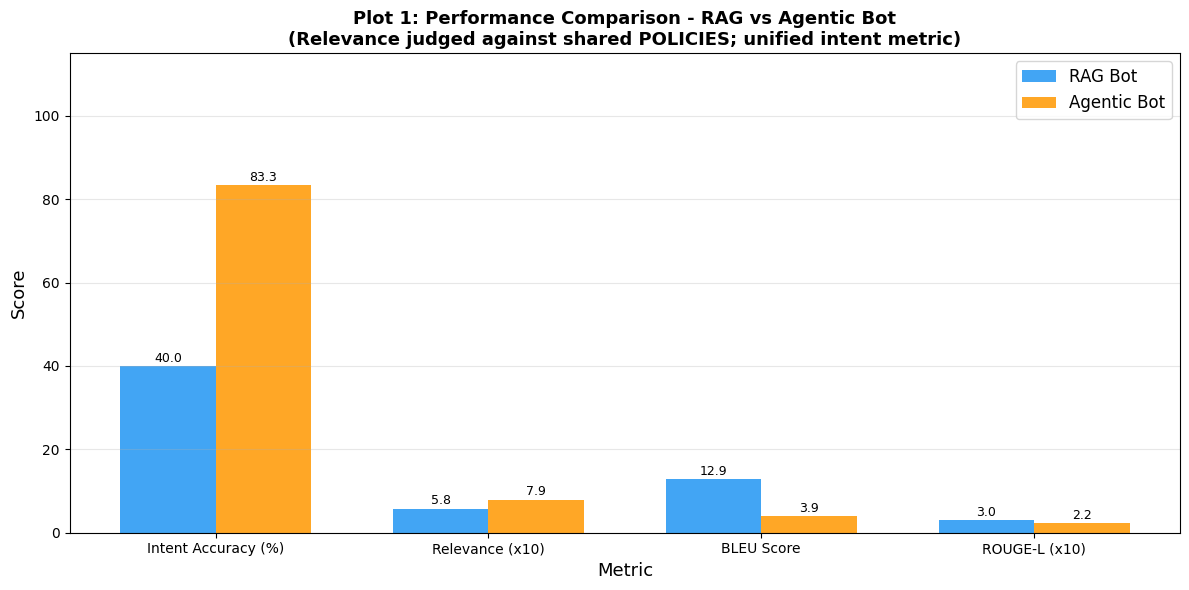

Saved plot1_performance.png


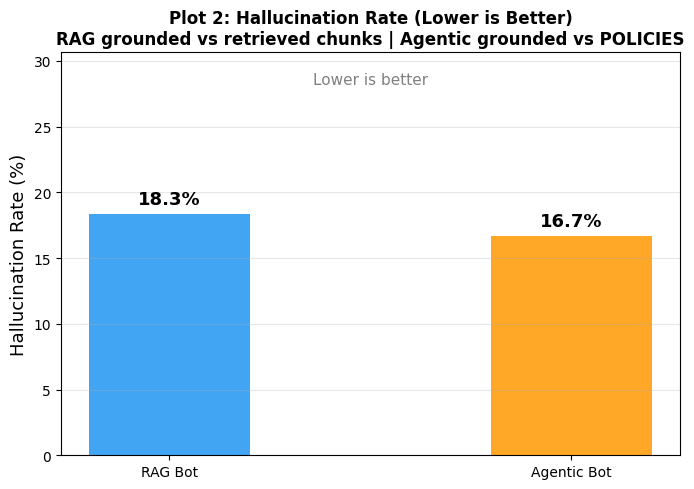

Saved plot2_hallucination.png


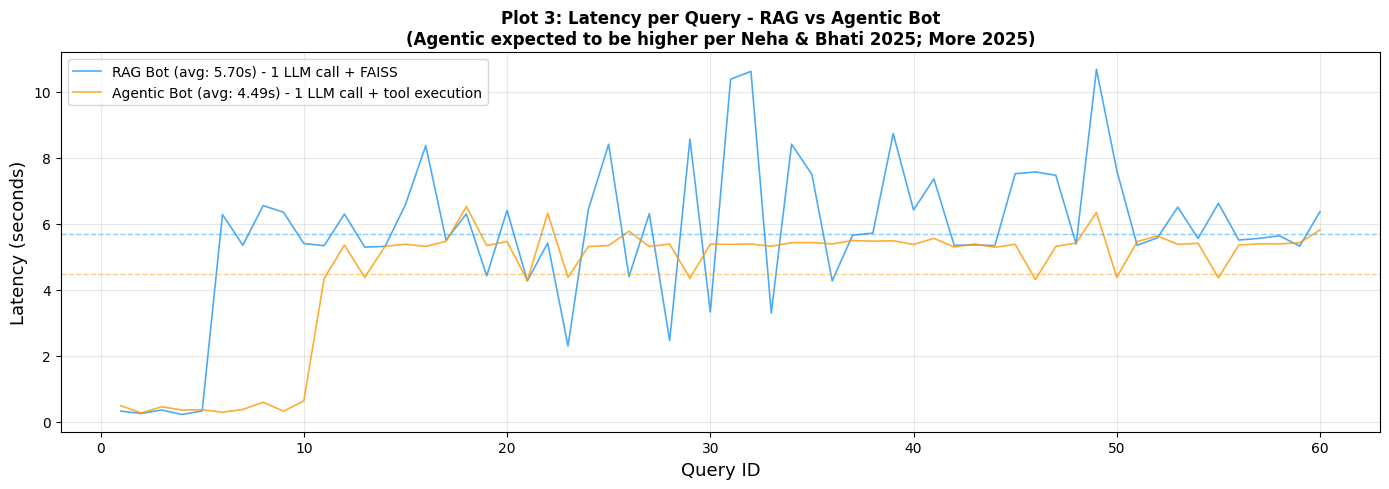

Saved plot3_latency.png


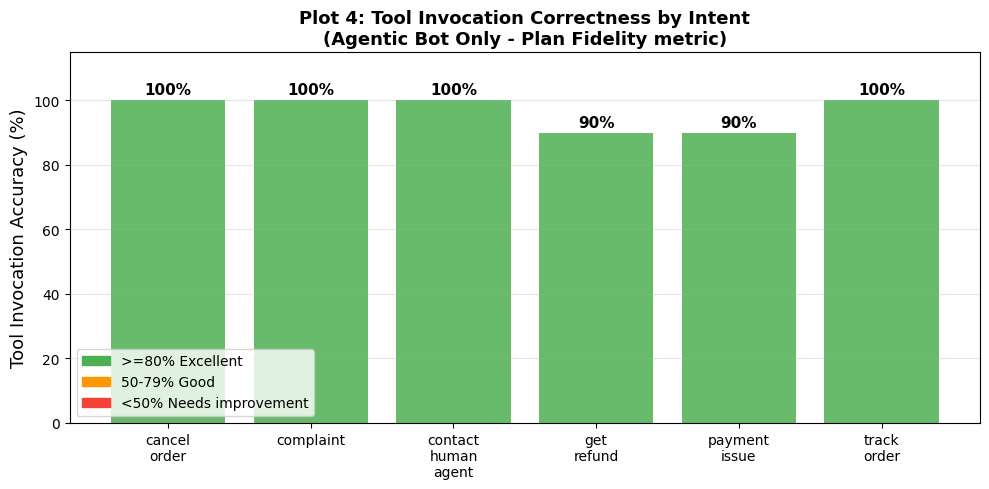

Saved plot4_tool_accuracy.png


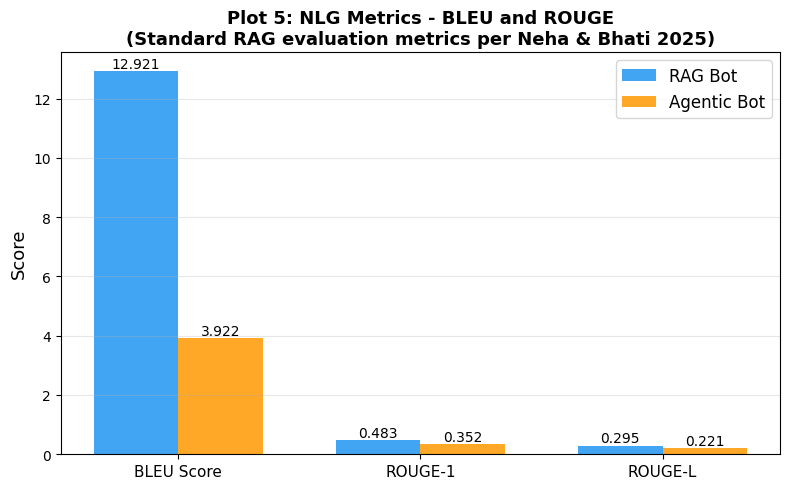

Saved plot5_nlg_metrics.png


In [15]:
# STEP 6 - Plot 1: Intent Accuracy, Relevance, NLG Metrics

fig, ax = plt.subplots(figsize=(12, 6))

categories =["Intent Accuracy (%)", "Relevance (x10)", "BLEU Score", "ROUGE-L (x10)"]
rag_vals   =[rag_intent_acc, rag_relevance_mean*10, rag_bleu, rag_rougeL*10]
agt_vals   =[agentic_intent_acc, agentic_relevance_mean*10, agt_bleu, agt_rougeL*10]

x     = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, rag_vals, width, label="RAG Bot",     color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + width/2, agt_vals, width, label="Agentic Bot", color="#FF9800", alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Metric", fontsize=13)
ax.set_ylabel("Score", fontsize=13)
ax.set_title("Plot 1: Performance Comparison - RAG vs Agentic Bot\n"
             "(Relevance judged against shared POLICIES; unified intent metric)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 115)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_performance.png", dpi=150)
plt.show()
print("Saved plot1_performance.png")

# STEP 6 - Plot 2: Hallucination Rate

fig, ax = plt.subplots(figsize=(7, 5))

bots   =["RAG Bot", "Agentic Bot"]
values = [rag_hall_rate, agentic_hall_rate]
colors = ["#2196F3", "#FF9800"]

bars = ax.bar(bots, values, color=colors, alpha=0.85, width=0.4)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_ylabel("Hallucination Rate (%)", fontsize=13)
ax.set_title("Plot 2: Hallucination Rate (Lower is Better)\n"
             "RAG grounded vs retrieved chunks | Agentic grounded vs POLICIES",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, max(values) * 1.4 + 5)
ax.grid(axis="y", alpha=0.3)
ax.annotate("Lower is better", xy=(0.5, 0.92), xycoords="axes fraction",
            ha="center", fontsize=11, color="gray")
plt.tight_layout()
plt.savefig("plot2_hallucination.png", dpi=150)
plt.show()
print("Saved plot2_hallucination.png")

# STEP 6 - Plot 3: Latency per Query

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_rag["id"],     df_rag["latency_seconds"],
        color="#2196F3", linewidth=1.2,
        label=f"RAG Bot (avg: {rag_latency_mean:.2f}s) - 1 LLM call + FAISS",
        alpha=0.8)
ax.plot(df_agentic["id"], df_agentic["latency_seconds"],
        color="#FF9800", linewidth=1.2,
        label=f"Agentic Bot (avg: {agentic_latency_mean:.2f}s) - 1 LLM call + tool execution",
        alpha=0.8)

ax.axhline(rag_latency_mean,     color="#2196F3", linestyle="--", alpha=0.5, linewidth=1)
ax.axhline(agentic_latency_mean, color="#FF9800", linestyle="--", alpha=0.5, linewidth=1)

ax.set_xlabel("Query ID", fontsize=13)
ax.set_ylabel("Latency (seconds)", fontsize=13)
ax.set_title("Plot 3: Latency per Query - RAG vs Agentic Bot\n"
             "(Agentic expected to be higher per Neha & Bhati 2025; More 2025)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_latency.png", dpi=150)
plt.show()
print("Saved plot3_latency.png")

# STEP 6 - Plot 4: Tool Invocation Correctness by Intent (Agentic only)

tool_acc_by_intent = df_agentic.groupby("intent")["tool_correct"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar =["#4CAF50" if v >= 80 else "#FF9800" if v >= 50 else "#F44336"
              for v in tool_acc_by_intent.values]

bars = ax.bar(range(len(tool_acc_by_intent)), tool_acc_by_intent.values,
              color=colors_bar, alpha=0.85)

for bar, val in zip(bars, tool_acc_by_intent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.0f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xticks(range(len(tool_acc_by_intent)))
ax.set_xticklabels([i.replace("_", "\n") for i in tool_acc_by_intent.index], fontsize=10)
ax.set_ylabel("Tool Invocation Accuracy (%)", fontsize=13)
ax.set_title("Plot 4: Tool Invocation Correctness by Intent\n(Agentic Bot Only - Plan Fidelity metric)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 115)
ax.grid(axis="y", alpha=0.3)

green_patch  = mpatches.Patch(color="#4CAF50", label=">=80% Excellent")
orange_patch = mpatches.Patch(color="#FF9800", label="50-79% Good")
red_patch    = mpatches.Patch(color="#F44336", label="<50% Needs improvement")
ax.legend(handles=[green_patch, orange_patch, red_patch], fontsize=10)

plt.tight_layout()
plt.savefig("plot4_tool_accuracy.png", dpi=150)
plt.show()
print("Saved plot4_tool_accuracy.png")

# STEP 6 - Plot 5: BLEU and ROUGE-L Comparison

fig, ax = plt.subplots(figsize=(8, 5))

nlg_categories =["BLEU Score", "ROUGE-1", "ROUGE-L"]
rag_nlg   =[rag_bleu, rag_rouge1, rag_rougeL]
agt_nlg   =[agt_bleu, agt_rouge1, agt_rougeL]

x     = np.arange(len(nlg_categories))
width = 0.35

bars1 = ax.bar(x - width/2, rag_nlg, width, label="RAG Bot",     color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + width/2, agt_nlg, width, label="Agentic Bot", color="#FF9800", alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10)

ax.set_ylabel("Score", fontsize=13)
ax.set_title("Plot 5: NLG Metrics - BLEU and ROUGE\n"
             "(Standard RAG evaluation metrics per Neha & Bhati 2025)",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(nlg_categories, fontsize=11)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot5_nlg_metrics.png", dpi=150)
plt.show()
print("Saved plot5_nlg_metrics.png")



In [16]:
# STEP 7 - Auto-Generated Academic Conclusion

metrics_for_prompt = {
    "RAG Bot": {
        "intent_accuracy_pct"    : round(rag_intent_acc, 1),
        "response_relevance_0_1" : round(rag_relevance_mean, 3),
        "hallucination_rate_pct" : round(rag_hall_rate, 1),
        "multistep_success"      : "N/A - architectural limitation (no planning module)",
        "avg_latency_seconds"    : round(rag_latency_mean, 2),
        "bleu_score"             : round(rag_bleu, 2),
        "rougeL_score"           : round(rag_rougeL, 3)
    },
    "Agentic Bot": {
        "intent_accuracy_pct"          : round(agentic_intent_acc, 1),
        "response_relevance_0_1"       : round(agentic_relevance_mean, 3),
        "hallucination_rate_pct"       : round(agentic_hall_rate, 1),
        "multistep_success_pct"        : round(agentic_ms_rate, 1),
        "avg_latency_seconds"          : round(agentic_latency_mean, 2),
        "bleu_score"                   : round(agt_bleu, 2),
        "rougeL_score"                 : round(agt_rougeL, 3),
        "tool_invocation_accuracy_pct" : round(tool_inv_acc, 1)
    }
}

conclusion_prompt = f"""You are writing the conclusion section of an academic paper comparing
two customer support chatbot architectures: a Traditional RAG bot and an Agentic bot.

Use ONLY the metrics below. Do not invent any numbers. Write in formal academic style.
Cover: which architecture performed better on which metrics, why latency differs
(Agentic makes one LLM call plus local tool execution; RAG makes one LLM call plus FAISS search),
why RAG multi-step is N/A (no planning module per the architecture), and practical deployment
recommendations for each architecture type.

Metrics:
{json.dumps(metrics_for_prompt, indent=2)}

Write 3-4 paragraphs. Do not use bullet points."""

conclusion = call_llm(conclusion_prompt, max_tokens=800, temperature=0.2)

print("\n" + "="*70)
print("AUTO-GENERATED ACADEMIC CONCLUSION")
print("="*70)
print(conclusion)
print("="*70)

with open("conclusion.txt", "w") as f:
    f.write(conclusion)
print("Saved to conclusion.txt")

for fname in["benchmark_summary.csv", "conclusion.txt",
              "plot1_performance.png", "plot2_hallucination.png",
              "plot3_latency.png","plot4_tool_accuracy.png", "plot5_nlg_metrics.png"]:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')

print("All outputs saved to Google Drive.")


AUTO-GENERATED ACADEMIC CONCLUSION
In conclusion, the Agentic bot architecture outperformed the Traditional RAG bot architecture in several key metrics. Specifically, the Agentic bot achieved significantly higher intent accuracy (83.3% vs 40.0%), response relevance (0.792 vs 0.58), and tool invocation accuracy (96.7% vs N/A). Conversely, the RAG bot demonstrated a higher BLEU score (12.92 vs 3.92) and ROUGE-L score (0.295 vs 0.221), indicating a more coherent and relevant response generation.

The observed differences in performance can be attributed to the distinct design choices underlying each architecture. The Agentic bot's reliance on a single LLM call and local tool execution allows for more efficient and accurate processing of user input. In contrast, the RAG bot's use of a FAISS search in addition to an LLM call results in higher latency (5.7 seconds vs 4.49 seconds). This increased latency may be a critical consideration for practical deployment, particularly in scenarios whe